In [ ]:
# ===================================================
# Build out the Game of Life with Cellular Automata
# ===================================================
# Requirements:
# There should be no explosive growth
# There should exist small initial patterns with chaotic, unpredictable outcomes
# There should be potential for von Neumann universal constructors
# The rules should be as simple as possible, within the above constraints
# ----------------------------------------------------
# Rules:
# Any live cell with fewer than two live neighbors dies, as if by underpopulation
# Any live cell with two or three live neighbors lives on to the next generation
# Any live cell with more than three live neighbors dies, as if by overpopulation
# Any dead cell with exactly three live neighbors becomes a live cell, as though by reproduction
# ====================================================

# =================
# Imports and Setup
# =================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ffmpeg
from IPython.display import HTML

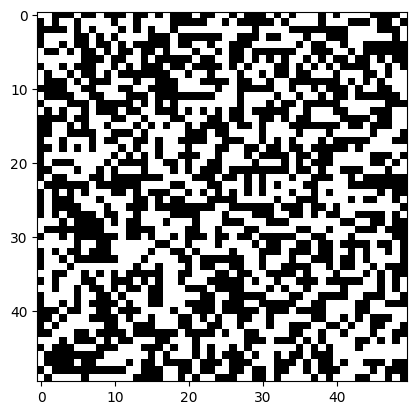

In [ ]:
# Randomly initiated grid
size = (50, 50) # Define the size of the grid
random_matrix = np.random.randint(0, 2, size=size, dtype=np.int8)
plt.imshow(random_matrix, cmap = 'Greys')

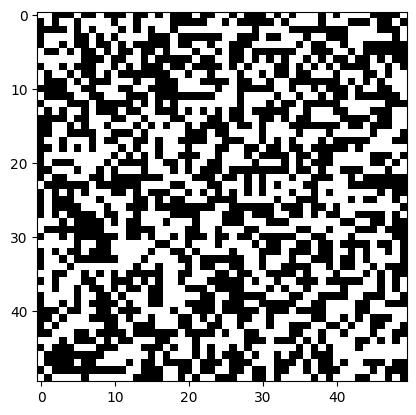

In [ ]:
# Initialize the random grid for the CA interpretation and implementation
Glidergun = np.copy(random_matrix)

# Place a glider pattern in the center of the Glidergun matrix for testing
# A glider pattern:
# 0 1 0
# 0 0 1
# 1 1 1
rows, cols = Glidergun.shape
center_row, center_col = rows // 2, cols // 2

# Ensure the glider fits within bounds
if center_row + 2 < rows and center_col + 2 < cols:
    Glidergun[center_row, center_col + 1] = 1
    Glidergun[center_row + 1, center_col + 2] = 1
    Glidergun[center_row + 2, center_col] = 1
    Glidergun[center_row + 2, center_col + 1] = 1
    Glidergun[center_row + 2, center_col + 2] = 1

plt.imshow(Glidergun, cmap = 'Greys')

In [ ]:
def tick(matrix):
  new_state = np.copy(matrix)
  rows, cols = matrix.shape
  for i in range(rows):
    for j in range(cols):
      neighbors = 0
      for dx in [-1, 0, 1]:
          for dy in [-1, 0, 1]:
              if dx == 0 and dy == 0:
                  continue # Skip the cell itself

              nx = (i + dx) % rows
              ny = (j + dy) % cols

              # Add neighbor value
              neighbors += matrix[nx, ny]

      # rules
      if matrix[i][j] == 0 and neighbors == 3: # reproduction
        new_state[i][j] = 1
      elif matrix[i][j] == 1 and neighbors < 2: # underpopulation
        new_state[i][j] = 0
      elif matrix[i][j] == 1 and neighbors > 3: # overpopulation
        new_state[i][j] = 0
      elif matrix[i][j] == 1 and (neighbors == 2 or neighbors == 3): # survives
        new_state[i][j] = 1
  return new_state

In [ ]:
def animate(frames, inputinterval, matrix):
  fig = plt.figure()

  ims = []
  current_state = np.copy(matrix) # Start with a copy of the initial state
  for i in range(frames):
    im = plt.imshow(current_state, animated = True, cmap = 'Greys')
    ims.append([im]) # Append the image of the current_state
    current_state = tick(current_state) # Compute the next state

  anim = animation.ArtistAnimation(fig, ims, interval = inputinterval, blit = True)
  plt.close(fig) # Close the figure to prevent it from being displayed as a static image
  return anim # Return the animation object

In [ ]:
anim_result = animate(frames=50,inputinterval=50,matrix=Glidergun)
HTML(anim_result.to_jshtml())

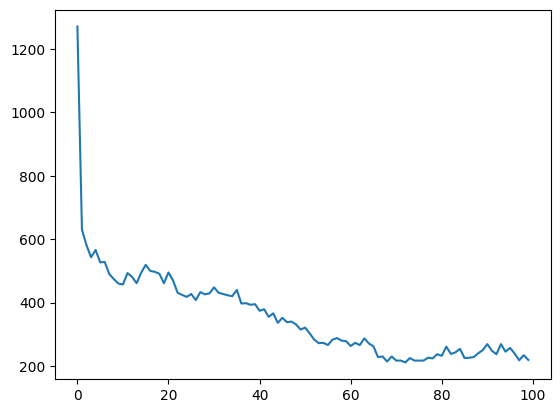

In [ ]:
# --------------------------------
# Expansion for Deeper Insights
# --------------------------------

# Measure Population over time
def population(matrix):
    return np.sum(matrix)

# Tracker Function
pop_history = []
current = np.copy(Glidergun)

for _ in range(100):
    pop_history.append(population(current))
    current = tick(current)

plt.plot(pop_history)

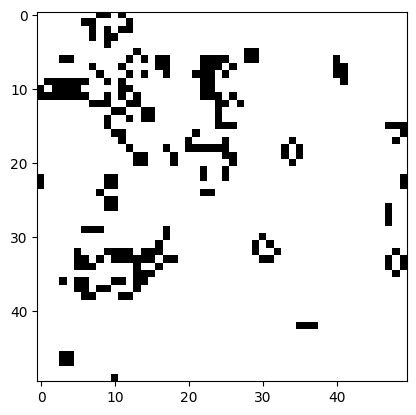

In [ ]:
# Who/What Survives
plt.imshow(current, cmap='Greys')